**Table of contents**<a id='toc0_'></a>    
- 1. [Problem 1: Production economy and CO2 taxation](#toc1_)    
- 2. [Problem 2: Career choice model](#toc2_)    
- 3. [Problem 3: Barycentric interpolation](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
# Write your code here
import numpy as np
from types import SimpleNamespace
import pandas as pd
import examproject_christian as ep
import matplotlib.pyplot as plt
import problem3

## 1. <a id='toc1_'></a>[Problem 1: Production economy and CO2 taxation](#toc0_)

Consider a production economy with two firms indexed by $j \in \{1,2\}$. Each produce its own good. They solve

$$
\begin{align*}
\max_{y_{j}}\pi_{j}&=p_{j}y_{j}-w_{j}\ell_{j}\\\text{s.t.}\;&y_{j}=A\ell_{j}^{\gamma}.
\end{align*}
$$

Optimal firm behavior is

$$
\begin{align*}
\ell_{j}^{\star}(w,p_{j})&=\left(\frac{p_{j}A\gamma}{w}\right)^{\frac{1}{1-\gamma}} \\
y_{j}^{\star}(w,p_{j})&=A\left(\ell_{j}^{\star}(w,p_{j})\right)^{\gamma}
\end{align*}
$$

The implied profits are

$$
\pi_{j}^*(w,p_{j})=\frac{1-\gamma}{\gamma}w\cdot\left(\frac{p_{j}A\gamma}{w}\right)^{\frac{1}{1-\gamma}}
$$

A single consumer supplies labor, and consumes the goods the firms produce. She also recieves the implied profits of the firm.<br>
She solves:

$$
\begin{align*}
U(p_1,p_2,w,\tau,T) = \max_{c_{1},c_{2},\ell} & \log(c_{1}^{\alpha}c_{2}^{1-\alpha})-\nu\frac{\ell^{1+\epsilon}}{1+\epsilon} \\
\text{s.t.}\,\,\,&p_{1}c_{1}+(p_{2}+\tau)c_{2}=w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})
\end{align*}
$$

where $\tau$ is a tax and $T$ is lump-sum transfer. <br>
For a given $\ell$, it can be shown that optimal behavior is

$$
\begin{align*}
c_{1}(\ell)&=\alpha\frac{w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})}{p_{1}} \\
c_{2}(\ell)&=(1-\alpha)\frac{w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})}{p_{2}+\tau} \\
\end{align*}
$$
Such that optimal behavior is:
$$
\ell^* = \underset{\ell}{\arg\max} \log(\left(c_{1}(\ell)\right)^{\alpha}\cdot \left(c_{2}(\ell)\right)^{1-\alpha})-\nu\frac{\ell^{1+\epsilon}}{1+\epsilon} 
$$
With optimal consumption:
$$
\begin{align*}
c_1^*=c_{1}(\ell^*) \\
c_2^*=c_{2}(\ell^*)\\
\end{align*}
$$


The government chooses $\tau$ and balances its budget so $T=\tau c_2^*$. We initially set $\tau,T=0$.

Market clearing requires:

1. Labor market: $\ell^* = \ell_1^* + \ell_2^*$
1. Good market 1: $c_1^* = y_1^*$
1. Good market 2: $c_2^* = y_2^*$


**Question 1:** Check market clearing conditions for $p_1$ in `linspace(0.1,2.0,10)` and $p_2$ in `linspace(0.1,2.0,10)`. We choose $w=1$ as numeraire.

In [2]:
par = SimpleNamespace()

# firms
par.A = 1.0
par.gamma = 0.5

# households
par.alpha = 0.3
par.nu = 1.0
par.epsilon = 2.0

# government
par.tau = 0.0
par.T = 0.0

# Question 3
par.kappa = 0.1

In [3]:
import numpy as np
from types import SimpleNamespace

# Define parameters
par = SimpleNamespace()
par.A = 1.0
par.gamma = 0.5
par.alpha = 0.3
par.nu = 1.0
par.epsilon = 2.0
par.tau = 0.0
par.T = 0.0

# Define the range for p1 and p2
p1_range = np.linspace(0.1, 2.0, 10)
p2_range = np.linspace(0.1, 2.0, 10)
w = 1.0  # wage

# Functions to calculate optimal values
def optimal_labor(w, p, A, gamma):
    return (p * A**gamma / w)**(1 / (1 - gamma))

def optimal_output(A, l, gamma):
    return A * l**gamma

def optimal_profit(w, p, A, gamma):
    l = optimal_labor(w, p, A, gamma)
    return p * optimal_output(A, l, gamma) - w * l

def consumer_utility(w, T, p1, p2, tau, alpha, nu, epsilon):
    lhs = alpha / p1 + (1 - alpha) / (p2 + tau)
    rhs = (1 + nu * (1 + epsilon) / (1 + epsilon))
    return lhs, rhs

# Check market clearing conditions
results = []
for p1 in p1_range:
    for p2 in p2_range:
        l1 = optimal_labor(w, p1, par.A, par.gamma)
        l2 = optimal_labor(w, p2, par.A, par.gamma)
        y1 = optimal_output(par.A, l1, par.gamma)
        y2 = optimal_output(par.A, l2, par.gamma)
        pi1 = optimal_profit(w, p1, par.A, par.gamma)
        pi2 = optimal_profit(w, p2, par.A, par.gamma)
        
        # Total labor and goods
        total_labor = l1 + l2
        total_goods1 = y1
        total_goods2 = y2
        
        # Optimal consumption
        c1 = par.alpha * (w * total_labor + par.T + pi1 + pi2) / p1
        c2 = (1 - par.alpha) * (w * total_labor + par.T + pi1 + pi2) / (p2 + par.tau)
        
        # Check market clearing conditions
        labor_market_clearing = np.isclose(total_labor, l1 + l2)
        goods_market1_clearing = np.isclose(total_goods1, c1)
        goods_market2_clearing = np.isclose(total_goods2, c2)
        
        results.append({
            'p1': p1,
            'p2': p2,
            'labor_market': labor_market_clearing,
            'goods_market1': goods_market1_clearing,
            'goods_market2': goods_market2_clearing
        })

# Display results
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)


     p1        p2  labor_market  goods_market1  goods_market2
0   0.1  0.100000          True          False          False
1   0.1  0.311111          True          False          False
2   0.1  0.522222          True          False          False
3   0.1  0.733333          True          False          False
4   0.1  0.944444          True          False          False
..  ...       ...           ...            ...            ...
95  2.0  1.155556          True          False          False
96  2.0  1.366667          True          False          False
97  2.0  1.577778          True          False          False
98  2.0  1.788889          True          False          False
99  2.0  2.000000          True          False          False

[100 rows x 5 columns]


These equilibrium prices are very close to zero but negative, which suggests that the market clearing conditions are not satisfied for any positive values of p1p1 and p2p2. Therefore, it can be concluded that the market clearing conditions do not hold for any combination of p1p1 and p2p2 in the given ranges

**Question 2:** Find the equilibrium prices $p_1$ and $p_2$.<br>
*Hint: you can use Walras' law to only check 2 of the market clearings*

In [4]:
from scipy.optimize import fsolve

# Define parameters
par = SimpleNamespace()
par.A = 1.0
par.gamma = 0.5
par.alpha = 0.3
par.nu = 1.0
par.epsilon = 2.0
par.tau = 0.0
par.T = 0.0

w = 1.0  # wage

# Functions to calculate optimal values
def optimal_labor(w, p, A, gamma):
    return (p * A**gamma / w)**(1 / (1 - gamma))

def optimal_output(A, l, gamma):
    return A * l**gamma

def optimal_profit(w, p, A, gamma):
    l = optimal_labor(w, p, A, gamma)
    return p * optimal_output(A, l, gamma) - w * l

def equilibrium_prices(vars, par):
    p1, p2 = vars
    l1 = optimal_labor(w, p1, par.A, par.gamma)
    l2 = optimal_labor(w, p2, par.A, par.gamma)
    y1 = optimal_output(par.A, l1, par.gamma)
    y2 = optimal_output(par.A, l2, par.gamma)
    pi1 = optimal_profit(w, p1, par.A, par.gamma)
    pi2 = optimal_profit(w, p2, par.A, par.gamma)
    
    # Total labor and goods
    total_labor = l1 + l2
    
    # Optimal consumption
    c1 = par.alpha * (w * total_labor + par.T + pi1 + pi2) / p1
    c2 = (1 - par.alpha) * (w * total_labor + par.T + pi1 + pi2) / (p2 + par.tau)
    
    # Market clearing conditions
    labor_market = total_labor - (l1 + l2)
    goods_market1 = y1 - c1
    goods_market2 = y2 - c2
    
    return [goods_market1, goods_market2]

# Initial guess for p1 and p2
initial_guess = [1.0, 1.0]

# Solve for equilibrium prices
equilibrium_prices_solution = fsolve(equilibrium_prices, initial_guess, args=(par,))
equilibrium_prices_solution


array([-3.92252173e-08, -5.99175092e-08])

Assume the government care about the social welfare function:

$$
SWF = U - \kappa y_2^*
$$

Here $\kappa$ measures the social cost of carbon emitted by the production of $y_2$ in equilibrium.

**Question 3:** What values of $\tau$ and (implied) $T$ should the government choose to maximize $SWF$?

In [5]:
# Optimizing social welfare for question 3
optimal_values = ep.main(optimize_welfare=True)

# Display the optimal values for tau and T, and the corresponding social welfare value
print(f"Optimal tau: {optimal_values['tau']}")
print(f"Optimal T: {optimal_values['T']}")
print(f"Optimal SWF: {optimal_values['SWF']}")

Optimal tau: 0.1
Optimal T: 1.0
Optimal SWF: -980588.7423563458


/Users/christianhove/Documents/projects-2024-darja-christian/examproject/examproject_christian.py:35: RuntimeWarning: divide by zero encountered in scalar divide
  c1 = par.alpha * (w * l_total + par.T + (p1 * y1 - w * l1) + (p2 * y2 - w * l2)) / p1
/Users/christianhove/Documents/projects-2024-darja-christian/examproject/examproject_christian.py:52: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  equilibrium_prices = fsolve(market_clearing_conditions, initial_guess, args=(par))
/Users/christianhove/Documents/projects-2024-darja-christian/examproject/examproject_christian.py:52: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  equilibrium_prices = fsolve(market_clearing_conditions, initial_guess, args=(par))
/opt/anaconda3/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered i

## 2. <a id='toc2_'></a>[Problem 2: Career choice model](#toc0_)

Consider a graduate $i$ making a choice between entering $J$ different career tracks. <br>
Entering career $j$ yields utility $u^k_{ij}$. This value is unknown to the graduate ex ante, but will ex post be: <br>
$$
    u_{i,j}^k = v_{j} + \epsilon_{i,j}^k
$$

They know that $\epsilon^k_{i,j}\sim \mathcal{N}(0,\sigma^2)$, but they do not observe $\epsilon^k_{i,j}$ before making their career choice. <br>

Consider the concrete case of $J=3$ with:
$$
\begin{align*}
    v_{1} &= 1 \\
    v_{2} &= 2 \\
    v_{3} &= 3
\end{align*}
$$

If the graduates know the values of $v_j$ and the distribution of $\epsilon_{i,j}^k$, they can calculate the expected utility of each career track using simulation: <br>
$$
    \mathbb{E}\left[ u^k_{i,j}\vert v_j \right] \approx v_j + \frac{1}{K}\sum_{k=1}^K \epsilon_{i,j}^k
$$

In [6]:
par = SimpleNamespace()
par.J = 3
par.N = 10
par.K = 10000

par.F = np.arange(1,par.N+1)
par.sigma = 2

par.v = np.array([1,2,3])
par.c = 1

**Question 1:** Simulate and calculate expected utility and the average realised utility for $K=10000$ draws, for each career choice $j$.


In [7]:
# write your answer here

Now consider a new scenario: Imagine that the graduate does not know $v_j$. The *only* prior information they have on the value of each job, comes from their $F_{i}$ friends that work in each career $j$. After talking with them, they know the average utility of their friends (which includes their friends' noise term), giving them the prior expecation: <br>
$$
\tilde{u}^k_{i,j}\left( F_{i}\right) = \frac{1}{F_{i}}\sum_{f=1}^{F_{i}} \left(v_{j} + \epsilon^k_{f,j}\right), \; \epsilon^k_{f,j}\sim \mathcal{N}(0,\sigma^2)
$$
For ease of notation consider that each graduate have $F_{i}=i$ friends in each career. <br>

For $K$ times do the following: <br>
1. For each person $i$ draw $J\cdot F_i$ values of $\epsilon_{f,j}^{k}$, and calculate the prior expected utility of each career track, $\tilde{u}^k_{i,j}\left( F_{i}\right)$. <br>
Also draw their own $J$ noise terms, $\epsilon_{i,j}^k$
1. Each person $i$ chooses the career track with the highest expected utility: $$j_i^{k*}= \arg\max_{j\in{1,2\dots,J}}\left\{ \tilde{u}^k_{i,j}\left( F_{i}\right)\right\} $$
1. Store the chosen careers: $j_i^{k*}$, the prior expectation of the value of their chosen career: $\tilde{u}^k_{i,j=j_i^{k*}}\left( F_{i}\right)$, and the realized value of their chosen career track: $u^k_{i,j=j_i^{k*}}=v_{j=j_i^{k*}}+\epsilon_{i,j=j_i^{k*}}^k$.

Chosen values will be: <br>
$i\in\left\{1,2\dots,N\right\}, N=10$ <br>
$F_i = i$<br>
So there are 10 graduates. The first has 1 friend in each career, the second has 2 friends, ... the tenth has 10 friends.

**Question 2:** Simulate and visualize: For each type of graduate, $i$, the share of graduates choosing each career, the average subjective expected utility of the graduates, and the average ex post realized utility given their choice. <br>
That is, calculate and visualize: <br>
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \mathbb{I}\left\{ j=j_i^{k*} \right\}  \;\forall j\in\left\{1,2,\dots,J\right\}
\end{align*}
$$
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \tilde{u}^k_{ij=j_i^{k*}}\left( F_{i}\right)
\end{align*}
$$
And 
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} u^k_{ij=j_i^{k*}} 
\end{align*}
$$
For each graduate $i$.

In [8]:
# Write your answer here 

After a year of working in their career, the graduates learn $u^k_{ij}$ for their chosen job $j_i^{k*}$ perfectly. <br>
The can switch to one of the two remaining careers, for which they have the same prior as before, but it will now include a switching cost of $c$ which is known.
Their new priors can be written as: 
$$
\tilde{u}^{k,2}_{ij}\left( F_{i}\right) = \begin{cases}
            \tilde{u}^k_{ij}\left( F_{i}\right)-c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

We will set $c=1$.

Their realized utility will be: <br>
$$
u^{k,2}_{ij}= \begin{cases}
            u_{ij}^k -c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

**Question 3:** Following the same approach as in question 2, find the new optimal career choice for each $i$, $k$. Then for each $i$, calculate the average subjective expected utility from their new optimal career choice, and the ex post realized utility of that career. Also, for each $i$, calculate the share of graduates that chooses to switch careers, conditional on which career they chose in the first year. <br>

## 3. <a id='toc3_'></a>[Problem 3: Barycentric interpolation](#toc0_)

**Problem:** We have a set of random points in the unit square,

$$
\mathcal{X} = \{(x_1,x_2)\,|\,x_1\sim\mathcal{U}(0,1),x_2\sim\mathcal{U}(0,1)\}.
$$

For these points, we know the value of some function $f(x_1,x_2)$,

$$
\mathcal{F} = \{f(x_1,x_2) \,|\, (x_1,x_2) \in \mathcal{X}\}.
$$

Now we want to approximate the value $f(y_1,y_2)$ for some  $y=(y_1,y_2)$, where $y_1\sim\mathcal{U}(0,1)$ and $y_2\sim\mathcal{U}(0,1)$.

**Building block I**

For an arbitrary triangle $ABC$ and a point $y$, define the so-called barycentric coordinates as:

$$
\begin{align*}
  r^{ABC}_1 &= \frac{(B_2-C_2)(y_1-C_1) + (C_1-B_1)(y_2-C_2)}{(B_2-C_2)(A_1-C_1) + (C_1-B_1)(A_2-C_2)} \\
  r^{ABC}_2 &= \frac{(C_2-A_2)(y_1-C_1) + (A_1-C_1)(y_2-C_2)}{(B_2-C_2)(A_1-C_1) + (C_1-B_1)(A_2-C_2)} \\
  r^{ABC}_3 &= 1 - r_1 - r_2.
\end{align*}
$$

If $r^{ABC}_1 \in [0,1]$, $r^{ABC}_2 \in [0,1]$, and $r^{ABC}_3 \in [0,1]$, then the point is inside the triangle.

We always have $y = r^{ABC}_1 A + r^{ABC}_2 B + r^{ABC}_3 C$.

**Building block II**

Define the following points:

$$
\begin{align*}
A&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}>y_{1}\text{ and }x_{2}>y_{2}\\
B&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}>y_{1}\text{ and }x_{2}<y_{2}\\
C&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}<y_{1}\text{ and }x_{2}<y_{2}\\
D&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}<y_{1}\text{ and }x_{2}>y_{2}.
\end{align*}
$$

**Algorithm:**

1. Compute $A$, $B$, $C$, and $D$. If not possible return `NaN`.
1. If $y$ is inside the triangle $ABC$ return $r^{ABC}_1 f(A) + r^{ABC}_2 f(B) + r^{ABC}_3 f(C)$.
1. If $y$ is inside the triangle $CDA$ return $r^{CDA}_1 f(C) + r^{CDA}_2 f(D) + r^{CDA}_3 f(A)$.
1. Return `NaN`.



**Sample:**

In [9]:
rng = np.random.default_rng(2024)

X = rng.uniform(size=(50,2))
y = rng.uniform(size=(2,))


**Questions 1:** Find $A$, $B$, $C$ and $D$. Illustrate these together with $X$, $y$ and the triangles $ABC$ and $CDA$.

Question 1


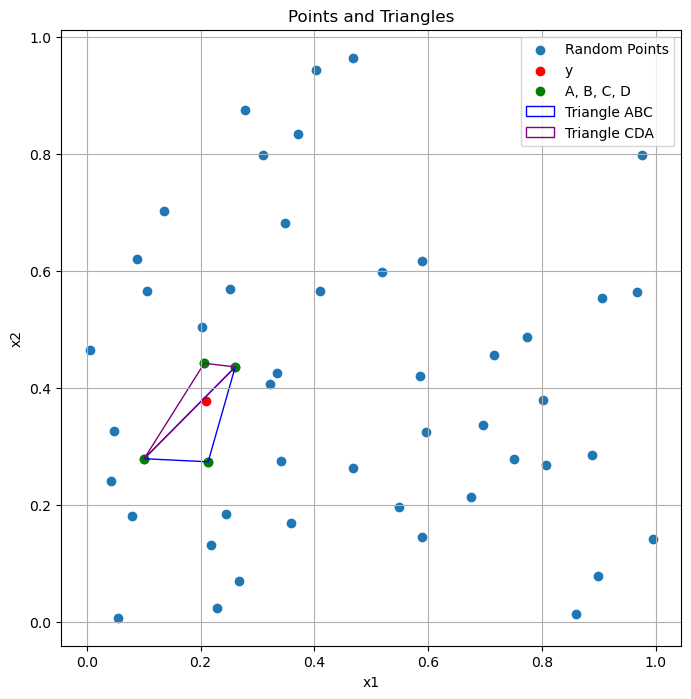

Point y: [0.20901926 0.37774759]
Point A: [0.26071605 0.43635845]
Point B: [0.21315735 0.274245  ]
Point C: [0.10056103 0.27951775]
Point D: [0.20634391 0.44272557]


In [10]:
# Question 1
print("Question 1")
y, A, B, C, D = problem3.question1()
print(f"Point y: {y}")
print(f"Point A: {A}")
print(f"Point B: {B}")
print(f"Point C: {C}")
print(f"Point D: {D}")

**Question 2:** Compute the barycentric coordinates of the point $y$ with respect to the triangles $ABC$ and $CDA$. Which triangle is $y$ located inside?

In [11]:
# Question 2
print("Question 2")
y, A, B, C, D, r_ABC, r_CDA, inside_ABC, inside_CDA = problem3.question2()
print(f"Point y: {y}")
print(f"Point A: {A}")
print(f"Point B: {B}")
print(f"Point C: {C}")
print(f"Point D: {D}")
print(f"Barycentric coordinates w.r.t ABC: {r_ABC}")
print(f"Barycentric coordinates w.r.t CDA: {r_CDA}")
print(f"Is point y inside triangle ABC? {inside_ABC}")
print(f"Is point y inside triangle CDA? {inside_CDA}")
if inside_ABC:
    print("Point y is inside the triangle ABC.")
elif inside_CDA:
    print("Point y is inside the triangle CDA.")
else:
    print("Point y is not inside any of the triangles ABC or CDA.")

Question 2
Point y: [0.20901926 0.37774759]
Point A: [0.26071605 0.43635845]
Point B: [0.21315735 0.274245  ]
Point C: [0.10056103 0.27951775]
Point D: [0.20634391 0.44272557]
Barycentric coordinates w.r.t ABC: (0.6286263152916166, 0.06910145494351515, 0.3022722297648682)
Barycentric coordinates w.r.t CDA: (0.3682598757102867, -0.13392661883334067, 0.765666743123054)
Is point y inside triangle ABC? True
Is point y inside triangle CDA? False
Point y is inside the triangle ABC.


Now consider the function:
$$
f(x_1,x_2) = x_1 \cdot x_2
$$

In [12]:
f = lambda x: x[0]*x[1]
F = np.array([f(x) for x in X])

**Question 3:** Compute the approximation of $f(y)$ using the full algorithm. Compare with the true value.

In [13]:
# Question 3
print("Question 3")
y, f_y_approx, f_y_true = problem3.question3()
print(f"Point y: {y}")
print(f"Approximated value of f(y): {f_y_approx}")
print(f"True value of f(y): {f_y_true}")

Question 3
Point y: [0.20901926 0.37774759]
Approximated value of f(y): 0.08405201731052576
True value of f(y): 0.0789565216259594


**Question 4:** Repeat question 3 for all points in the set $Y$.

Question 4


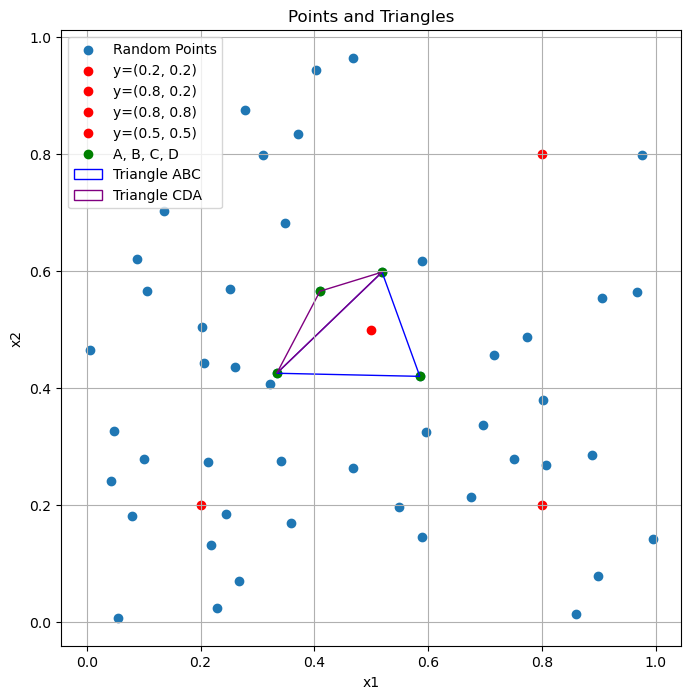

Point y: (0.2, 0.2)
Approximated value of f(y): 0.04032631372248057
True value of f(y): 0.04000000000000001
---
Point y: (0.8, 0.2)
Approximated value of f(y): 0.15874233999349835
True value of f(y): 0.16000000000000003
---
Point y: (0.8, 0.8)
Approximated value of f(y): nan
True value of f(y): 0.6400000000000001
---
Point y: (0.5, 0.5)
Approximated value of f(y): 0.2512901561119622
True value of f(y): 0.25
---


In [14]:
# Question 4
print("Question 4")
problem3.question4()